<a href="https://colab.research.google.com/github/Yiiize/MSSP6070/blob/main/Assignments/Case_Study_Report_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Yiiize' # Replace with the GitHub repository owner
repository = 'MSSP6070' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")


Changed directory to: /content/MSSP6070


In [5]:
import pandas as pd

file_path = '/content/MSSP6070/data/HousingPrices.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded data from: {file_path}")
print("First 5 rows of the DataFrame:")
print(df.head())

Successfully loaded data from: /content/MSSP6070/data/HousingPrices.csv
First 5 rows of the DataFrame:
   Id  LotFrontage  LotArea HouseStyle  OverallQual  OverallCond  YearBuilt  \
0   1         65.0   8450.0     2Story            7            5       2003   
1   2         80.0   9600.0     1Story            6            8       1976   
2   3         68.0  11250.0     2Story            7            5       2001   
3   4         60.0   9550.0     2Story            7            5       1915   
4   5         84.0  14260.0     2Story            8            5       2000   

   TotalBsmtSF CentralAir  1stFlrSF  2ndFlrSF  FullBath  TotalRooms  \
0        856.0          Y       856       854         2           8   
1          NaN          Y      1262         0         2           6   
2        920.0          Y       920       866         2           6   
3          NaN          Y       961       756         1           7   
4       1145.0          Y      1145      1053         2           9

In [6]:
print("Descriptive statistics for the DataFrame:")
print(df.describe())

Descriptive statistics for the DataFrame:
                Id  LotFrontage        LotArea  OverallQual  OverallCond  \
count  1460.000000  1201.000000    1341.000000  1460.000000  1460.000000   
mean    730.500000    70.049958   10440.099925     6.099315     5.575342   
std     421.610009    24.284752   10051.013206     1.382997     1.112799   
min       1.000000    21.000000    1300.000000     1.000000     1.000000   
25%     365.750000    59.000000    7500.000000     5.000000     5.000000   
50%     730.500000    69.000000    9382.000000     6.000000     5.000000   
75%    1095.250000    80.000000   11500.000000     7.000000     6.000000   
max    1460.000000   313.000000  215245.000000    10.000000     9.000000   

         YearBuilt  TotalBsmtSF     1stFlrSF     2ndFlrSF     FullBath  \
count  1460.000000   913.000000  1460.000000  1460.000000  1460.000000   
mean   1971.267808  1055.813801  1162.626712   346.992466     1.565068   
std      30.202904   409.495459   386.587738   436.

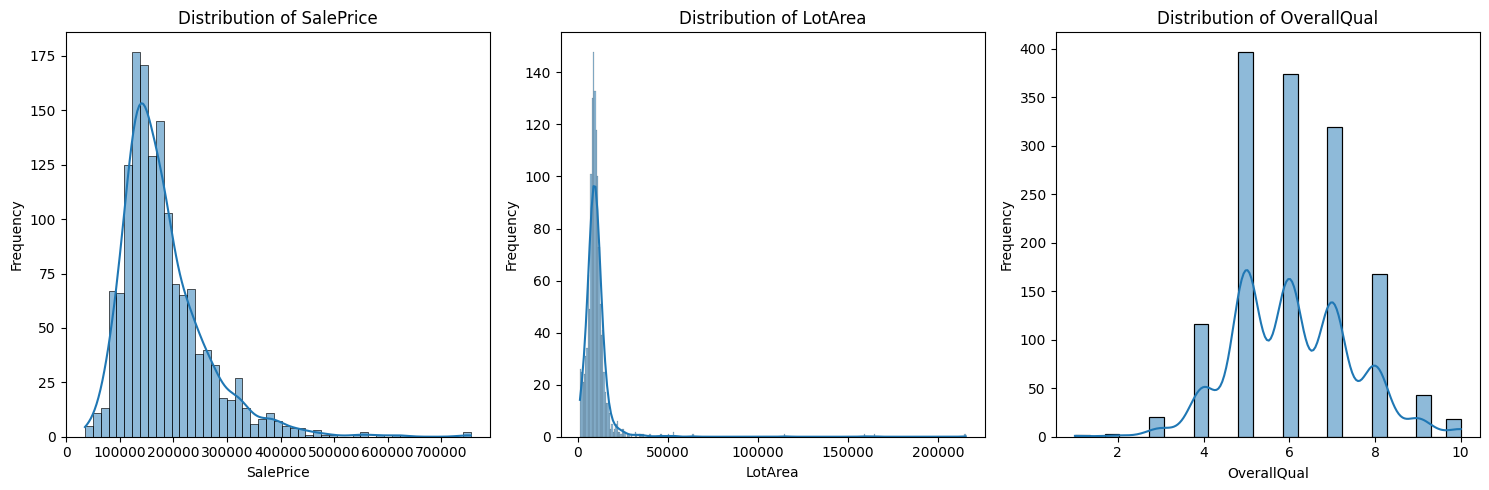

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for better visualization
plt.figure(figsize=(15, 5))

# Histogram for SalePrice
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

# Histogram for LotArea
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.histplot(df['LotArea'].dropna(), kde=True) # Drop NaNs for plotting
plt.title('Distribution of LotArea')
plt.xlabel('LotArea')
plt.ylabel('Frequency')

# Histogram for OverallQual
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.histplot(df['OverallQual'], kde=True)
plt.title('Distribution of OverallQual')
plt.xlabel('OverallQual')
plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

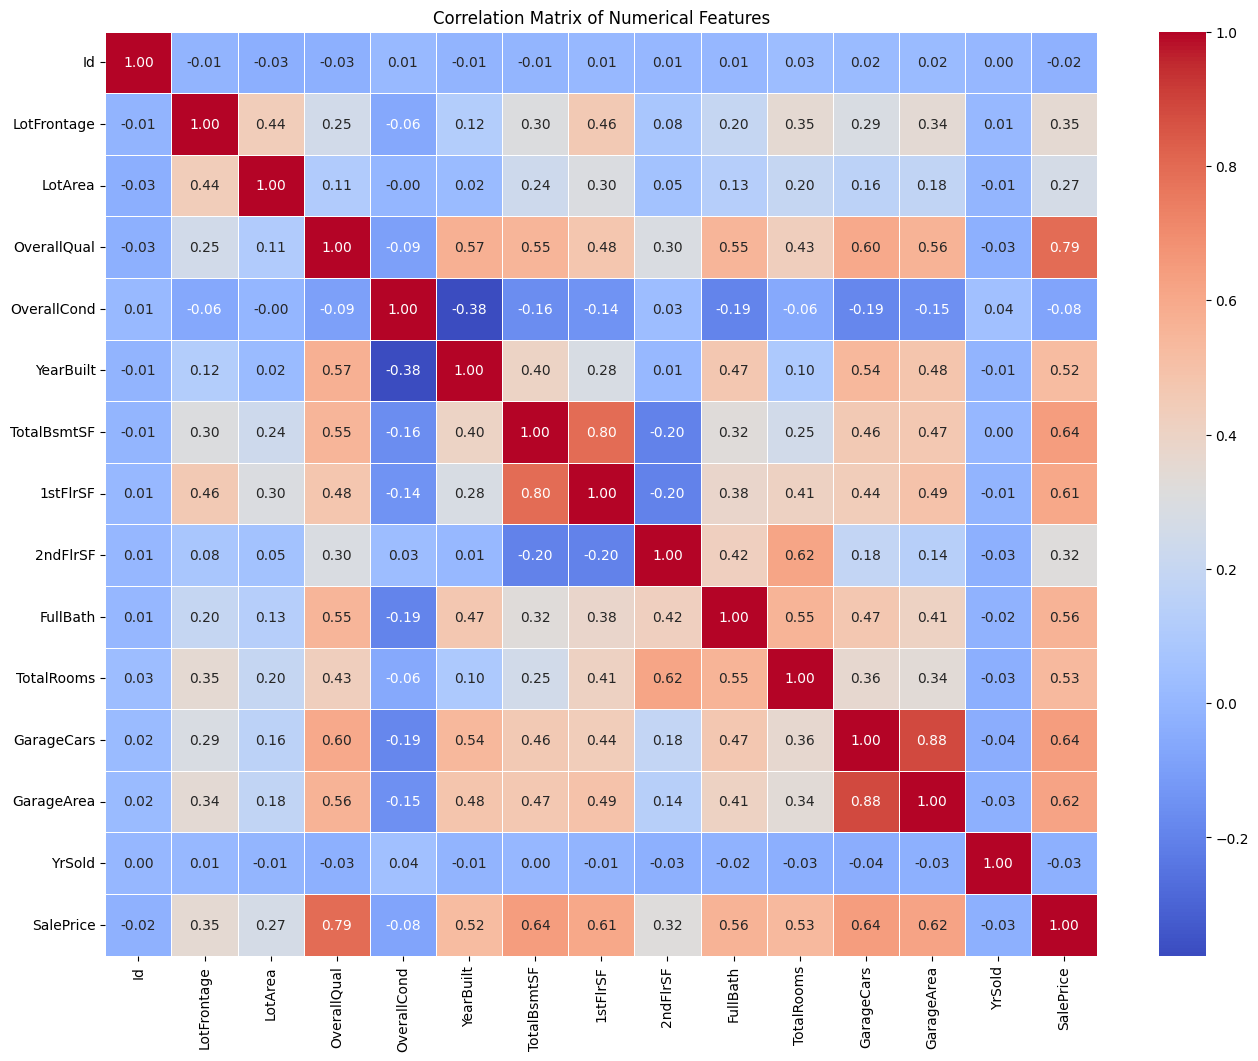

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


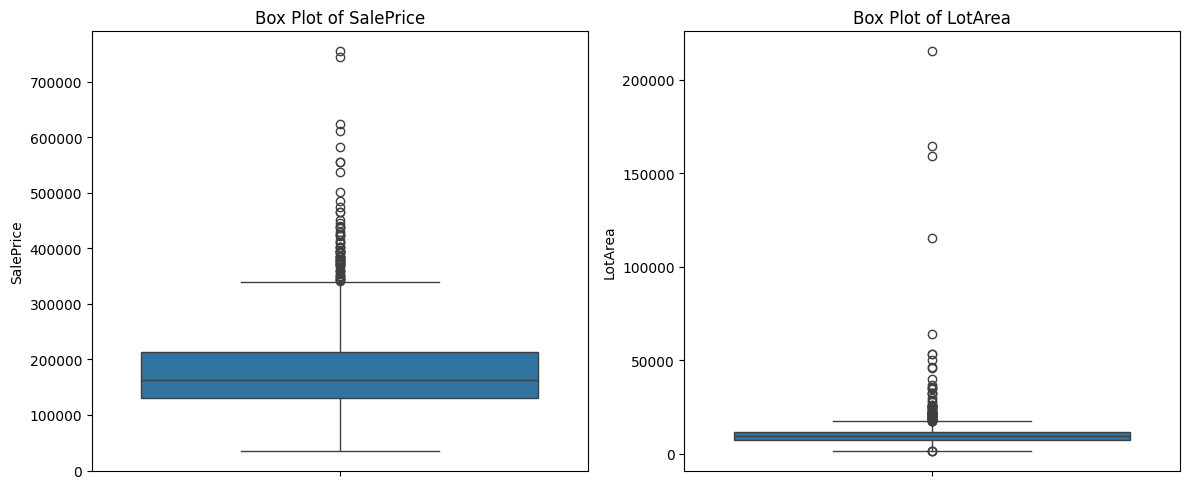

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Box plot for SalePrice
plt.subplot(1, 2, 1)
sns.boxplot(y=df['SalePrice'])
plt.title('Box Plot of SalePrice')
plt.ylabel('SalePrice')

# Box plot for LotArea
plt.subplot(1, 2, 2)
sns.boxplot(y=df['LotArea'].dropna())
plt.title('Box Plot of LotArea')
plt.ylabel('LotArea')

plt.tight_layout()
plt.show()

In [10]:
print("\nNumber of missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Also look at the unique values and their counts for some categorical columns
print("\nUnique values and counts for 'HouseStyle':")
print(df['HouseStyle'].value_counts())

print("\nUnique values and counts for 'CentralAir':")
print(df['CentralAir'].value_counts())


Number of missing values per column:
LotFrontage    259
LotArea        119
TotalBsmtSF    547
dtype: int64

Unique values and counts for 'HouseStyle':
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

Unique values and counts for 'CentralAir':
CentralAir
Y    1365
N      95
Name: count, dtype: int64
